In [2]:
import sys
sys.path.append("../../")

%load_ext autoreload
%autoreload 2

In [3]:
import dsrl.offline_safety_gymnasium  # type: ignore
import gymnasium as gym
import joblib
import math
import functools

import dsrl.infos as dsrl_infos
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# t-SNE plot import
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


from dsrl_model.utils.models_jax import ExpCostModel, TransformerEmbedding, positionalencoding1d, l2_normalize
from dsrl_model.utils.dsrl_dataset import get_dataset_in_d4rl_format, get_neg_and_union_data_2
from dsrl_model.model_free.safecl_jax import index_fun

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [4]:
def get_data(data, start=0, end=-1):
    observations, actions, costs = data["observations"], data["actions"], data["costs"]
    end = end if end < 0 else min(end, observations.shape[0])
    return (jnp.array(observations[start:end]),
            jnp.array(actions[start:end]),
            jnp.array(costs[start:end]))

In [5]:
def load_cost_model(obs_dim, act_dim, hidden_size, path):
    restored_pure_dict = joblib.load(path)
    
    model = ExpCostModel(
        rngs=nnx.Rngs(0), x_dims=(obs_dim + act_dim), hidden_size=hidden_size
    )
    abstract_model = nnx.eval_shape(lambda: model)
    graphdef, abstract_state = nnx.split(abstract_model)
    nnx.replace_by_pure_dict(abstract_state, restored_pure_dict)
    cost_model = nnx.merge(graphdef, abstract_state)
    cost_model.eval()
    return cost_model


def load_embedding_model(obs_dim, act_dim, horizon, embd_dim, num_attentions, path):
    restored_pure_dict = joblib.load(path)
    restored_pure_dict.pop('mask')
    restored_pure_dict.pop('pos_encoding')
    
    model = TransformerEmbedding(
        rngs=nnx.Rngs(0), 
        obs_dim=obs_dim,
        act_dim=act_dim,
        horizon=horizon,
        embd_dim=embd_dim,
        num_attentions=num_attentions,
    )
    abstract_model = nnx.eval_shape(lambda: model)
    graphdef, abstract_state = nnx.split(abstract_model)
    nnx.replace_by_pure_dict(abstract_state, restored_pure_dict)
    embedding_model = nnx.merge(graphdef, abstract_state)
    
    embedding_model.mask = jnp.tril(jnp.ones((horizon, horizon)))
    embedding_model.pos_encoding = positionalencoding1d(embd_dim, horizon)
    
    embedding_model.eval()
    return embedding_model

In [6]:
def get_env(task):
    env = gym.make(task)
    obs_space, act_space = env.observation_space, env.action_space
    return env, obs_space.shape[0], act_space.shape[0]

In [7]:
@nnx.jit
def get_embedding(embedding_model, observations, actions, norm=False):
    observations, actions = jnp.array(observations), jnp.array(actions)
 
    def normalize(obs):
        mu, std = jnp.mean(obs, axis=(0, 1)), jnp.std(obs, axis=(0,1))
        return (obs - mu) / (std + 1e-6)

    observations = jnp.where(norm, normalize(observations), observations)
    z = embedding_model(jnp.concat([observations, actions], axis=-1), training=False)
    return z

@jax.jit
def predict_trajectory_label(embeddings, neg_z, all_labels, label_range):
    multimode_score = embeddings @ neg_z
    score = jnp.max(multimode_score, axis=-1)
    new_labels = index_fun(score, all_labels, label_range)
    return new_labels, multimode_score


@jax.jit
def get_true_cost(costs):
    costs = jnp.array(costs)
    return jnp.sum(costs, axis=1).squeeze()
    

@nnx.jit
def get_pred_cost(cost_model, observations, actions, norm=False):
    observations, actions = jnp.array(observations), jnp.array(actions)
 
    def normalize(obs):
        mu, std = jnp.mean(obs, axis=(0, 1)), jnp.std(obs, axis=(0,1))
        return (obs - mu) / (std + 1e-6)

    observations = jnp.where(norm, normalize(observations), observations)
    transition_cost = cost_model(jnp.concat([observations, actions], axis=-1))
    trajectory_cost = jnp.sum(transition_cost, axis=1).squeeze()
    return trajectory_cost


def filter_cost_embedding_by_indx(data, group_data_idxs, embeddings):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    group_embds = []
    for data_idxs in group_data_idxs:
        filter_embds = []
        for i in range(dones_idx.shape[0]):
            if i not in data_idxs:
                continue
            start = 0 if i == 0 else dones_idx[i - 1] + 1
            end = dones_idx[i] + 1
            rep_embds = np.sum(embeddings[start:end], axis=0, keepdims=True)
            filter_embds.append(rep_embds)
        filter_embds = np.concatenate(filter_embds, axis=0)
        filter_embds = filter_embds / np.linalg.norm(filter_embds, axis=1, keepdims=True)
        group_embds.append(filter_embds)
    return group_embds


def get_tsne_vectors(group_embeddings, dim=3, seed=0, do_norm=False):
    tsne = TSNE(n_components=dim, perplexity=50, random_state=seed, init='random')
    
    embds_size = [embds.shape[0] for embds in group_embeddings]
    embds_ends = np.cumsum(embds_size)
    group_embeddings = np.concatenate(group_embeddings, axis=0)
    vec = tsne.fit_transform(group_embeddings)
    if do_norm:
        vec = vec / np.linalg.norm(vec, axis=1, keepdims=True)
    
    group_vec = []
    for i in range(len(embds_ends)):
        start = 0 if i==0 else embds_ends[i-1]
        end = embds_ends[i]
        group_vec.append(vec[start:end])

    return group_vec

In [8]:
def visualize_multimode(multimode_scores, true_cost, all_labels, label_range, task_name):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    eps = 1e-6
    
    idxs = jnp.sum(multimode_scores[:, :, None] <= label_range[1:], axis=-1)
    multimode_labels = all_labels[idxs].astype(jnp.int32)
    
    n = all_labels.shape[0] - 1
    count_matrix = np.zeros((n,n), dtype=np.float32)
    sum_cost_matrix = np.zeros((n,n), dtype=np.float32)
    square_cost_matrix = np.zeros((n,n), dtype=np.float32)
    for i, xy in enumerate(multimode_labels):
        x, y = xy
        sum_cost_matrix[x, y] += true_cost[i]
        square_cost_matrix[x, y] += (true_cost[i] * true_cost[i])
        count_matrix[x, y] += 1
    mean_cost_matrix = sum_cost_matrix / (count_matrix + eps)    
    std_cost_matrix = np.sqrt(
        square_cost_matrix / (count_matrix + eps) - (mean_cost_matrix  * mean_cost_matrix)
    )
    
    cax = ax.imshow(mean_cost_matrix, cmap="cividis", interpolation="nearest", origin="lower")
    cbar = fig.colorbar(cax, ax=ax)
    
    for i in range(n):
        for j in range(n):
            cost = mean_cost_matrix[i, j]
            std = std_cost_matrix[i, j]
            ax.text(j, i, f'{cost:.1f}' + r'$\pm$' + f'{std:.1f}', 
                    ha='center', # Horizontal alignment
                    va='center', # Vertical alignment
                    color='black', # Choose a contrasting color
                    fontsize=12) # Adjust size as needed
    
    # remove the last invalid label from the all_label array
    ax.set_xticks(all_labels[:-1][::-1])
    ax.set_yticks(all_labels[:-1][::-1])
    ax.set_title(task_name.replace("_", " "), fontsize='x-large')
    ax.set_xlabel("mode 1", fontsize='x-large')
    ax.set_ylabel("mode 2", fontsize='x-large')
    return fig
    

In [9]:
trajectory_cfg = {
    "density": 1.0,
    "target_cost": 25.0,
    # ((low_cost, low_reward), (high_cost, low_reward), (medium_cost, high_reward))
    "inpaint_ranges": ((0.0, 1.0, 0.0, 0.5),),
    "num_negative_trajectories": 50,
    "num_union_trajectories": -1,
    "non_pref_noise": 0.0,
}

In [10]:
labels_cfg = {
    "num_modes": 2,
    "labels": [3.0, 2.0, 1.0, 0.0] + [-1.0],  # -1 denotes invalid label
    "range": [1.0, 0.5, 0.0, -0.5, -1.0] + [-2.0],  # -2 denotes invalid range
    "distance": [1.0, 0.5, -0.5, -1.0] + [-2.0],  # -2 denotes invalid distance
}

all_labels = jnp.array(labels_cfg["labels"], dtype=jnp.float32)
label_distance = jnp.array(labels_cfg["distance"], dtype=jnp.float32)
label_range = jnp.array(labels_cfg["range"], dtype=jnp.float32)

In [11]:
task_name = "Point_Button1"
ver = 0
tn = task_name.replace("_", "")
task = f"Offline{tn}Gymnasium-v{ver}"

gamma = 0.99

is_norm = True
norm_type = "norm" if is_norm else "no_norm"

hidden_size = 256

embd_dim = 128
horizon = 1000
num_attentions = 2

eps = 1e-6

neg_z_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/state.pkl"
embedding_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/embedding_model_1000000.pt"
cost_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/cost_model_1000000.pt"

In [12]:
env, obs_dim, act_dim = get_env(task)
main_data = get_dataset_in_d4rl_format(env, trajectory_cfg, task, 1000)

In [10]:
neg_data, union_data = get_neg_and_union_data_2(main_data, trajectory_cfg)
del main_data

Number of negative trajectory dataset: 50
Avg negative trajectory cost/reward: 172.820/174.348
Number of union trajectory dataset: 513
Avg union trajectory cost/reward: 108.731/160.516


In [11]:
neg_z = jnp.array(joblib.load(neg_z_path)['target_neg_z'])

embedding_model = load_embedding_model(
    obs_dim=obs_dim,
    act_dim=act_dim,
    horizon=horizon,
    embd_dim=embd_dim,
    num_attentions=num_attentions,
    path=embedding_path,
)

In [ ]:
cost_model = load_cost_model(
    obs_dim=obs_dim,
    act_dim=act_dim,
    hidden_size=hidden_size,
    path=cost_path,
)

In [26]:
def embedding_labels_cost(
    union_data,
    embedding_model,
    neg_z,
    all_labels,
    label_range,
    is_norm,
    num=10
):
    l_pred_embs, l_pred_scores, l_pred_labels, l_true_cost = [], [], [], []
    start, end_len = 0, len(union_data['observations'])
    
    while start < end_len:
        end = start + num
        
        observations, actions, costs = get_data(union_data, start, end)
        embeddings = get_embedding(embedding_model, observations, actions, is_norm)
        pred_labels, multimode_score = predict_trajectory_label(embeddings, neg_z, all_labels, label_range)
        true_costs = get_true_cost(costs)

        l_pred_embs.append(embeddings)
        l_pred_scores.append(multimode_score)
        l_pred_labels.append(pred_labels)
        l_true_cost.append(true_costs)
        
        start = end
    
    return (jnp.concat(l_pred_embs, axis=0),
            jnp.concat(l_pred_scores, axis=0),
            jnp.concat(l_pred_labels),
            jnp.concat(l_true_cost))

In [27]:
embeddings, pred_scores, pred_labels, true_costs = embedding_labels_cost(
    union_data=union_data,
    embedding_model=embedding_model,
    neg_z=neg_z,
    all_labels=all_labels,
    label_range=label_range,
    is_norm=is_norm,
    num=50
)

In [53]:
idx = jnp.sum(pred_scores[:, :, None] <= label_range[1:], axis=-1)
multimode_labels = all_labels[idx].astype(jnp.int32)

In [95]:
count_matrix = np.zeros((4, 4), dtype=np.float32)
cost_matrix = np.zeros((4, 4), dtype=np.float32)
square_matrix = np.zeros((4, 4), dtype=np.float32)
for i, xy in enumerate(multimode_labels):
    x, y = xy
    cost_matrix[x, y] +=  true_costs[i]
    square_matrix[x,y] += true_costs[i] * true_costs[i]
    count_matrix[x, y] += 1

mean_cost_matrix = cost_matrix / (count_matrix + eps)
std_cost_matrix = np.sqrt(square_matrix / (count_matrix + eps) - (mean_cost_matrix  * mean_cost_matrix))

In [96]:
std_cost_matrix

array([[ 0.       , 36.6812   , 39.795364 , 13.509329 ],
       [ 0.125    , 54.378674 , 57.988503 , 29.082722 ],
       [43.71769  , 71.98304  ,  0.1711633, 32.32963  ],
       [52.09346  , 62.203735 , 50.428226 , 28.755774 ]], dtype=float32)

In [97]:
mean_cost_matrix

array([[  0.      ,  43.55263 ,  36.260868, 108.99998 ],
       [129.99988 ,  54.39999 ,  63.99998 , 136.44443 ],
       [127.874985, 112.66663 , 169.99983 , 152.50725 ],
       [ 37.777775, 110.37874 , 140.67856 , 150.66663 ]], dtype=float32)

In [64]:
cost_matrix

array([[  0.      ,  43.55263 ,  36.260868, 109.      ],
       [130.      ,  54.4     ,  64.      , 136.44444 ],
       [127.875   , 112.666664, 170.      , 152.50722 ],
       [ 37.77778 , 110.37874 , 140.67857 , 150.66667 ]], dtype=float32)

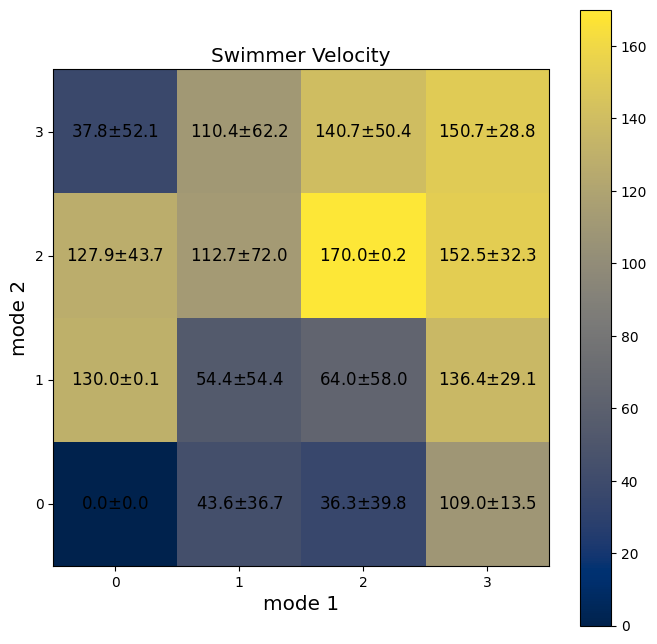

In [115]:
fig = visualize_multimode(pred_scores, true_costs, all_labels, label_range, task_name)

#### NN based target

In [13]:
model1 = TransformerEmbedding(
        rngs=nnx.Rngs(0), 
        obs_dim=obs_dim,
        act_dim=act_dim,
        horizon=100,
        embd_dim=embd_dim,
        num_attentions=num_attentions,
    )

model2 = TransformerEmbedding(
        rngs=nnx.Rngs(13), 
        obs_dim=obs_dim,
        act_dim=act_dim,
        horizon=100,
        embd_dim=embd_dim,
        num_attentions=3,

    )

In [14]:
key = jax.random.PRNGKey(0)
r = jax.random.normal(key=key, shape=(32, 100, obs_dim+act_dim))

In [15]:
z1 = model1(r, training=False)
z2 = model2(r, training=False)

In [16]:
jnp.einsum("ij,ij->i", z1, z2)

Array([ 0.0074787 ,  0.06002655,  0.08689655,  0.09369391,  0.16183268,
        0.09380711,  0.04966401,  0.1115236 ,  0.01988813,  0.09005217,
        0.07070477, -0.07376831,  0.02372983, -0.0107938 ,  0.16768037,
        0.01269658,  0.00111571, -0.0469263 ,  0.00951684,  0.04666883,
        0.05275911,  0.03168996,  0.05763179,  0.06597352,  0.00520258,
        0.07466348,  0.12866458,  0.14035243,  0.02181611,  0.09274537,
        0.12663719,  0.07208955], dtype=float32)

In [19]:
jnp.min(z1 @ z1.T), jnp.mean(z1 @ z1.T)

(Array(0.34987766, dtype=float32), Array(0.60247034, dtype=float32))